<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-50] Epoch   1/100 | LR: 3.77e-04 | train loss 1.0058 acc 0.539 | val loss 0.8303 acc 0.703 *


[ResNet-50] Epoch   2/100 | LR: 3.77e-04 | train loss 0.6675 acc 0.687 | val loss 0.5986 acc 0.782 *


[ResNet-50] Epoch   3/100 | LR: 3.77e-04 | train loss 0.5794 acc 0.746 | val loss 0.5700 acc 0.764 *


[ResNet-50] Epoch   4/100 | LR: 3.77e-04 | train loss 0.4602 acc 0.801 | val loss 0.6565 acc 0.683


...

[ResNet-50] Epoch  24/100 | LR: 3.77e-05 | train loss 0.0377 acc 0.985 | val loss 0.5674 acc 0.871


[ResNet-50] Epoch  25/100 | LR: 3.77e-05 | train loss 0.0309 acc 0.986 | val loss 0.5710 acc 0.865


[ResNet-50] Epoch  26/100 | LR: 3.77e-05 | train loss 0.0295 acc 0.989 | val loss 0.5682 acc 0.869


[ResNet-50] Epoch  27/100 | LR: 3.77e-05 | train loss 0.0254 acc 0.988 | val loss 0.5693 acc 0.871


[ResNet-50] Epoch  28/100 | LR: 3.77e-05 | train loss 0.0206 acc 0.990 | val loss 0.5840 acc 0.873

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 28.

[ResNet-50] Restored best checkpoint (val loss = 0.4355)


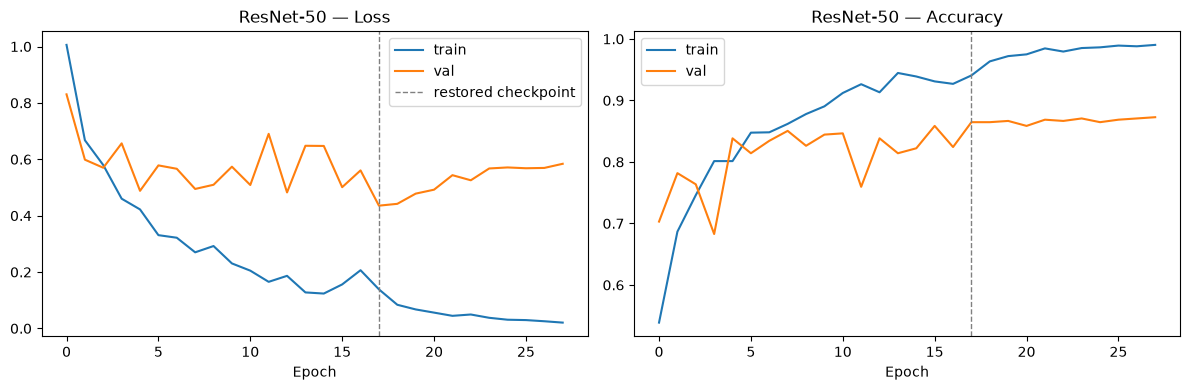

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.836


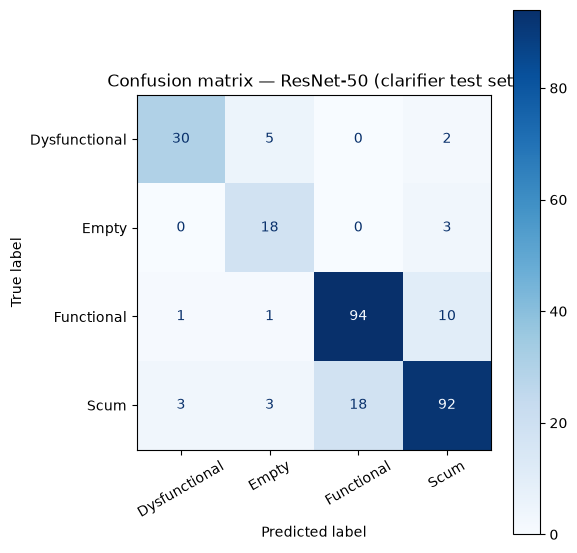

               precision    recall  f1-score   support

Dysfunctional      0.882     0.811     0.845        37
        Empty      0.667     0.857     0.750        21
   Functional      0.839     0.887     0.862       106
         Scum      0.860     0.793     0.825       116

     accuracy                          0.836       280
    macro avg      0.812     0.837     0.821       280
 weighted avg      0.841     0.836     0.836       280



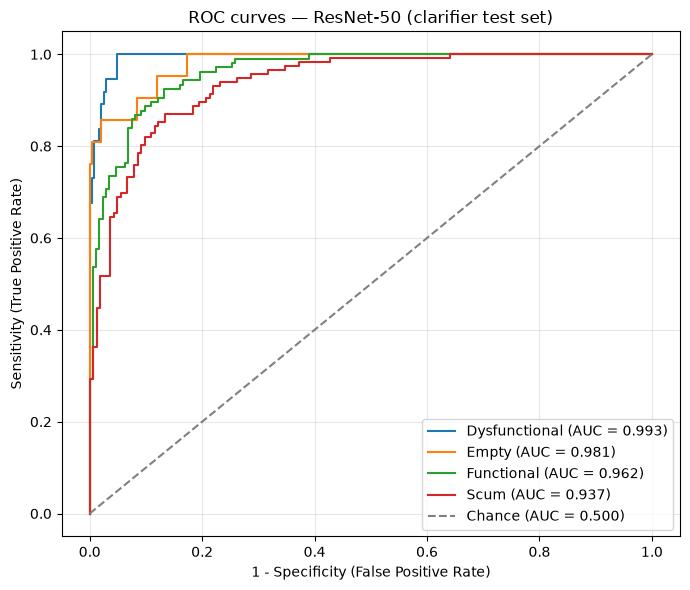

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.993
  Empty          : 0.981
  Functional     : 0.962
  Scum           : 0.937

Mean AUC (over 4/4 classes with test examples): 0.968


(np.float64(0.8357142857142857),
 {'Dysfunctional': 0.9934378823267712,
  'Empty': 0.9808788380216952,
  'Functional': 0.9617219692040773,
  'Scum': 0.936764087468461})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/clarifier_aug/results_clarifier_resnet50_stratified.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
